# Notebook 1 — Exploring the Chest X-ray Dataset (EDA)
### AIMI High School Internship

Before building *any* model, a researcher first *looks at the data*. **Exploratory Data Analysis (EDA)** is how you find out what you actually have: how many images, how they're labeled, whether the classes are balanced, and what traps might mislead a model later. Skipping it is how people train models that secretly cheat.

Dataset 1 — chest X-rays already split into `train` / `val` / `test`, each with a labels table. Positive (pneumonia) cases also carry a **bounding box** around the affected region. We'll explore the **train** split here.

Every later notebook (classification, localization, bias analysis) builds on choices you can only make well *after* understanding the data. Today you build that understanding.

## What you'll do in this notebook

1. **Setup** — one cell loads the data and the tools.
2. **What files do we have?** — get oriented: folders, image counts, label tables.
3. **The labels** — read the CSV, understand every column, and the box-per-patient structure.
4. **What is a DICOM? (a short aside)** — the clinical image format these JPGs came from.
5. **Examples from each class** — actually look at X-rays, with pneumonia boxes drawn.
6. **Distributions & geometry** — class balance, box sizes/locations, image consistency.
7. **Metadata-driven EDA** — age, sex, and view position, and how they relate to the label.
8. **Hypotheses worth testing** — turn observations into questions a model could exploit.
9. **Limitations** — what this data does *not* tell us.

# 1. Setup

> Before running: **Runtime → Change runtime type → T4 GPU** is not required for EDA (no training here), but it doesn't hurt.

Run the two cells below once. The first holds the only settings you might edit; the second loads the data and imports everything.

In [4]:
#@title Notebook settings { display-mode: "form" }
from pathlib import Path
# Put `dataset_1.zip` in your Google Drive ("My Drive"), then run all cells.
DATA_DIR = Path("/content/drive/MyDrive/dataset_1")

In [5]:
#@title Run setup (imports · data) { display-mode: "form" }
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches      # rectangles for bounding boxes
from PIL import Image                      # read JPGs (and their dimensions)

# Mount Google Drive so we can read the dataset (skipped automatically off Colab).
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

# Unzip the dataset to Colab's local disk and read from there. Reading images over the Drive
# mount re-fetches each file from the network on every read (slow); we unzip the dataset's
# .zip once to /content instead. Students put dataset_1.zip / dataset_2.zip in their Drive
# (My Drive). Skipped when DATA_DIR already points at local data (validation / off-Colab).
import zipfile
DATA_DIR = Path(DATA_DIR)
if str(DATA_DIR).startswith("/content/drive/"):
    local = Path("/content") / DATA_DIR.name
    if not local.exists():
        zip_path = Path("/content/drive/MyDrive") / f"{DATA_DIR.name}.zip"
        assert zip_path.exists(), (
            f"{zip_path} not found — add {DATA_DIR.name}.zip to your Google Drive (My Drive).")
        print(f"Unzipping {DATA_DIR.name}.zip to local disk (one-time)...")
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(local)                            # everything lands under /content/<name>
        kids = [p for p in local.iterdir() if not p.name.startswith((".", "__"))]
        if len(kids) == 1 and kids[0].is_dir():            # zip wrapped files in one extra folder
            import shutil
            for it in list(kids[0].iterdir()):
                shutil.move(str(it), str(local / it.name))
            kids[0].rmdir()
    DATA_DIR = local
assert DATA_DIR.exists(), f"dataset not found at {DATA_DIR}."
TRAIN_IMG_DIR = DATA_DIR / "train_images"
VAL_IMG_DIR   = DATA_DIR / "val_images"
TEST_IMG_DIR  = DATA_DIR / "test_images"

# The train labels table. Each ROW is one bounding box; positive patients have
# several rows, negatives have one row with empty box columns.
train_labels = pd.read_csv(DATA_DIR / "train_labels.csv")

SAMPLE_SEED = 42                                 # keeps sampled tables stable across runs
print("Data at:", DATA_DIR)
print(f"train_labels: {train_labels.shape[0]} rows, {train_labels['patientId'].nunique()} unique patients")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzipping dataset_1.zip to local disk (one-time)...
Data at: /content/dataset_1
train_labels: 3456 rows, 3000 unique patients


# 2. What files do we have?

Get oriented before touching labels: what folders exist, how many images are in each split, and which tables we were given.

In [6]:
def count_jpgs(d):
    """Count real .jpg files in a folder (ignoring macOS '._' junk)."""
    return sum(1 for f in os.listdir(d) if f.endswith(".jpg") and not f.startswith("._"))

print("Image folders (one X-ray per file, named by patientId):")
for name, d in [("train_images", TRAIN_IMG_DIR), ("val_images", VAL_IMG_DIR), ("test_images", TEST_IMG_DIR)]:
    print(f"  {name:14s}: {count_jpgs(d):5d} images")

print("\nLabel tables:")
for f in ["train_labels.csv", "val_labels.csv", "sample_submission.csv"]:
    p = DATA_DIR / f
    if p.exists():
        n = sum(1 for _ in open(p)) - 1
        print(f"  {f:22s}: {n} rows")

Image folders (one X-ray per file, named by patientId):
  train_images  :  3000 images
  val_images    :  1500 images
  test_images   :  1500 images

Label tables:
  train_labels.csv      : 3456 rows
  val_labels.csv        : 1723 rows
  sample_submission.csv : 1500 rows


Two things to notice:

- There are **three splits already provided** — `train`, `val`, `test` — so unlike the raw Kaggle data, you don't have to make your own split.
- The **test split has no labels**: it ships only with `sample_submission.csv` (a format template). Test labels are held back so the leaderboard is a fair, unseen evaluation — exactly like a real ML competition.

# 3. The labels

`pandas` reads a CSV into a **DataFrame** (a table). `.head()` shows the first rows, `.shape` gives (rows, columns), and `.info()` lists the columns and how many values are present.

In [7]:
print("shape:", train_labels.shape)
train_labels.head()

shape: (3456, 12)


,patientId,x,y,width,height,class,PatientAge,PatientSex,ViewPosition,BodyPartExamined,Modality,Target
0,0100515c-5204-4f31-98e0-f35e4b00004a,703.0,416.0,84.0,77.0,Lung Opacity,28,F,PA,CHEST,CR,1
1,01027bc3-dc40-4165-a6c3-d6be2cb7ca34,NaN,NaN,NaN,NaN,Normal,43,M,PA,CHEST,CR,0
2,016b1f90-bb9a-4d3a-9c38-74af5fffd5b5,NaN,NaN,NaN,NaN,No Lung Opacity / Not Normal,54,M,PA,CHEST,CR,0
3,01a7353d-25bb-4ff8-916b-f50dd541dccf,214.0,582.0,239.0,133.0,Lung Opacity,52,F,AP,CHEST,CR,1
4,01a7353d-25bb-4ff8-916b-f50dd541dccf,664.0,540.0,223.0,203.0,Lung Opacity,52,F,AP,CHEST,CR,1


In [ ]:
train_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3456 entries, 0 to 3455
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   patientId         3456 non-null   object 
 1   x                 1206 non-null   float64
 2   y                 1206 non-null   float64
 3   width             1206 non-null   float64
 4   height            1206 non-null   float64
 5   class             3456 non-null   object 
 6   PatientAge        3456 non-null   int64  
 7   PatientSex        3456 non-null   object 
 8   ViewPosition      3456 non-null   object 
 9   BodyPartExamined  3456 non-null   object 
 10  Modality          3456 non-null   object 
 11  Target            3456 non-null   int64  
dtypes: float64(4), int64(2), object(6)
memory usage: 324.1+ KB


`train_labels.csv` columns:

- `patientId` — unique ID for each X-ray (also the image filename, `{patientId}.jpg`).
- `x, y, width, height` — a **bounding box** around suspected pneumonia. `(x, y)` is the top-left corner; width/height are in pixels. **Empty (`NaN`) when `Target = 0`** — a box is only given when there's pneumonia to locate.
- `class` — a 3-way label: `Normal`, `Lung Opacity` (= pneumonia), or `No Lung Opacity / Not Normal` (abnormal but not pneumonia).
- `Target` — `1` if pneumonia, else `0`.
- `PatientAge, PatientSex, ViewPosition, BodyPartExamined, Modality` — clinical metadata pulled from the original scan headers (we'll use these in Sections 7–8).

In [8]:
# One patient can have MORE THAN ONE box, which means more than one row.
n_rows, n_patients = len(train_labels), train_labels["patientId"].nunique()
print(f"rows: {n_rows} | unique patients: {n_patients} | extra rows from multi-box patients: {n_rows - n_patients}")

# Show a patient that has multiple boxes.
multi = train_labels["patientId"].value_counts()
multi_pid = multi[multi > 1].index[0]
train_labels[train_labels["patientId"] == multi_pid]

rows: 3456 | unique patients: 3000 | extra rows from multi-box patients: 456


,patientId,x,y,width,height,class,PatientAge,PatientSex,ViewPosition,BodyPartExamined,Modality,Target
3349,0e03c2d7-9cea-4dc7-8e91-794a8b3ff58d,654.0,444.0,160.0,103.0,Lung Opacity,62,F,AP,CHEST,CR,1
3350,0e03c2d7-9cea-4dc7-8e91-794a8b3ff58d,531.0,206.0,289.0,213.0,Lung Opacity,62,F,AP,CHEST,CR,1
3351,0e03c2d7-9cea-4dc7-8e91-794a8b3ff58d,686.0,545.0,128.0,106.0,Lung Opacity,62,F,AP,CHEST,CR,1
3352,0e03c2d7-9cea-4dc7-8e91-794a8b3ff58d,213.0,386.0,114.0,161.0,Lung Opacity,62,F,AP,CHEST,CR,1


For counting patients (and for sampling example images), we want **one row per patient**. Build that view now — you'll reuse `per_patient` throughout the notebook.

In [20]:
# A one-row-per-patient table with the columns we'll analyze.
# TODO: build `per_patient` = one row per patient.
# - start from train_labels
# - keep one row per patientId  (hint: .drop_duplicates("patientId"))
# - keep columns: patientId, Target, class, PatientAge, PatientSex, ViewPosition
# - .reset_index(drop=True)
per_patient = train_labels.drop_duplicates("patientId")
print("patients:", len(per_patient))
per_patient.head()

patients: 3000


,patientId,x,y,width,height,class,PatientAge,PatientSex,ViewPosition,BodyPartExamined,Modality,Target
0,0100515c-5204-4f31-98e0-f35e4b00004a,703.0,416.0,84.0,77.0,Lung Opacity,28,F,PA,CHEST,CR,1
1,01027bc3-dc40-4165-a6c3-d6be2cb7ca34,NaN,NaN,NaN,NaN,Normal,43,M,PA,CHEST,CR,0
2,016b1f90-bb9a-4d3a-9c38-74af5fffd5b5,NaN,NaN,NaN,NaN,No Lung Opacity / Not Normal,54,M,PA,CHEST,CR,0
3,01a7353d-25bb-4ff8-916b-f50dd541dccf,214.0,582.0,239.0,133.0,Lung Opacity,52,F,AP,CHEST,CR,1
5,01d4fa0f-97a0-4522-b0d8-134400db2a3e,222.0,258.0,194.0,436.0,Lung Opacity,59,F,AP,CHEST,CR,1


How does the 3-way `class` line up with the binary `Target`? A **crosstab** counts the combinations.

In [21]:
pd.crosstab(per_patient["class"], per_patient["Target"])

Target,0,1
class,,
Lung Opacity,0,750
No Lung Opacity / Not Normal,1259,0
Normal,991,0


`Lung Opacity` is exactly `Target = 1`. Both `Normal` and `No Lung Opacity / Not Normal` map to `Target = 0` — so the binary label **merges two very different groups** (truly normal vs. abnormal-but-not-pneumonia) into one. Worth remembering when a model struggles.

# 4. What is a DICOM? (a short aside)

In a hospital, X-rays aren't stored as JPGs — they're stored as **DICOM** (`.dcm`) files, the universal standard in medical imaging. A DICOM bundles two things:

1. the **pixel data** (the image itself), and
2. a **header** of metadata — patient age and sex, how the scan was acquired (`ViewPosition`: AP = front-to-back, PA = back-to-front), the device, and much more.

For this course we've **exported the DICOM pixels to ordinary JPGs** (faster to load, no special libraries) and pulled the useful header fields into the CSV columns you saw above (`PatientAge`, `PatientSex`, `ViewPosition`, …). So you get the clinical metadata *without* needing to parse DICOMs. Just know that in a real clinical pipeline you'd be reading `.dcm` files with a library like `pydicom`.

# 5. Examples from each class

Numbers only get you so far — **look at the images**. We'll view one patient from each of the three classes, with the pneumonia box drawn in red, then a grid of positive cases.

In [23]:
def load_image(patient_id, img_dir=None):
    """Load one X-ray JPG as a grayscale array."""
    img_dir = img_dir or TRAIN_IMG_DIR
    return np.array(Image.open(Path(img_dir) / f"{patient_id}.jpg").convert("L"))

def boxes_for(patient_id):
    """Bounding boxes for a patient as a list of (x, y, w, h); empty if none."""
    rows = train_labels[train_labels["patientId"] == patient_id]
    return [(r["x"], r["y"], r["width"], r["height"])
            for _, r in rows.iterrows() if pd.notna(r["x"])]

def show_patient(patient_id, ax):
    ax.imshow(load_image(patient_id), cmap="gray")
    for (x, y, w, h) in boxes_for(patient_id):
        ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="red", facecolor="none"))
    cls = per_patient.loc[per_patient["patientId"] == patient_id, "class"].iloc[0]
    ax.set_title(cls, fontsize=10); ax.axis("off")

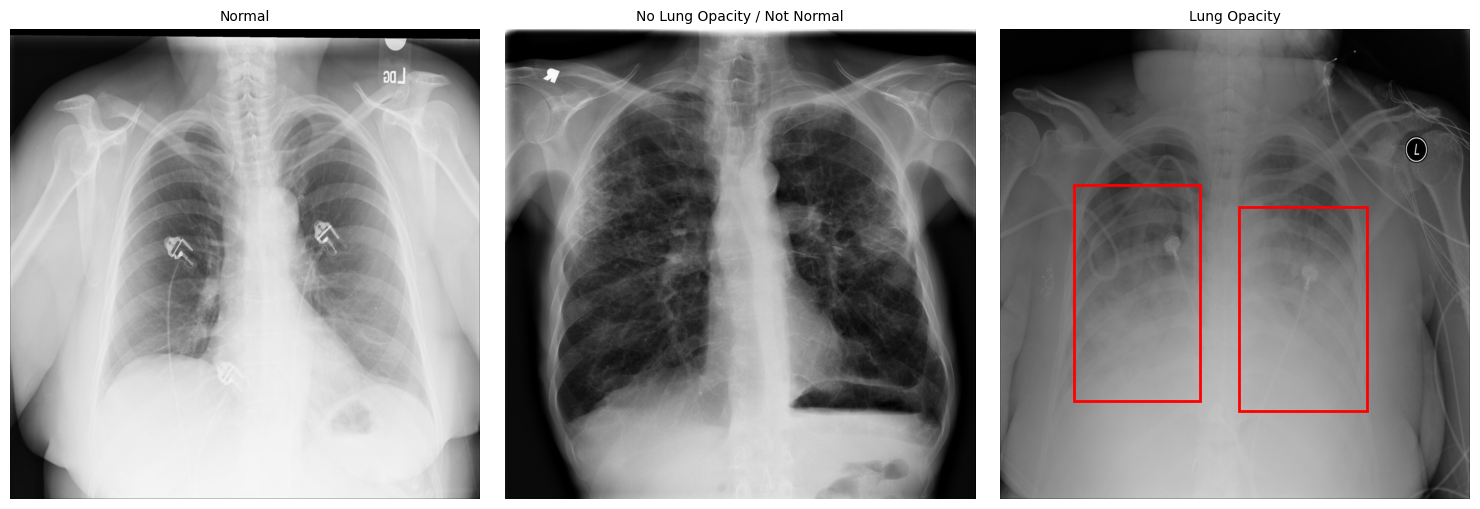

In [24]:
#@title One random patient per class (re-run for new examples) { display-mode: "form" }
order = ["Normal", "No Lung Opacity / Not Normal", "Lung Opacity"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, cls in zip(axes, order):
    pid = per_patient[per_patient["class"] == cls]["patientId"].sample(1, random_state=None).iloc[0]
    show_patient(pid, ax)
plt.tight_layout(); plt.show()

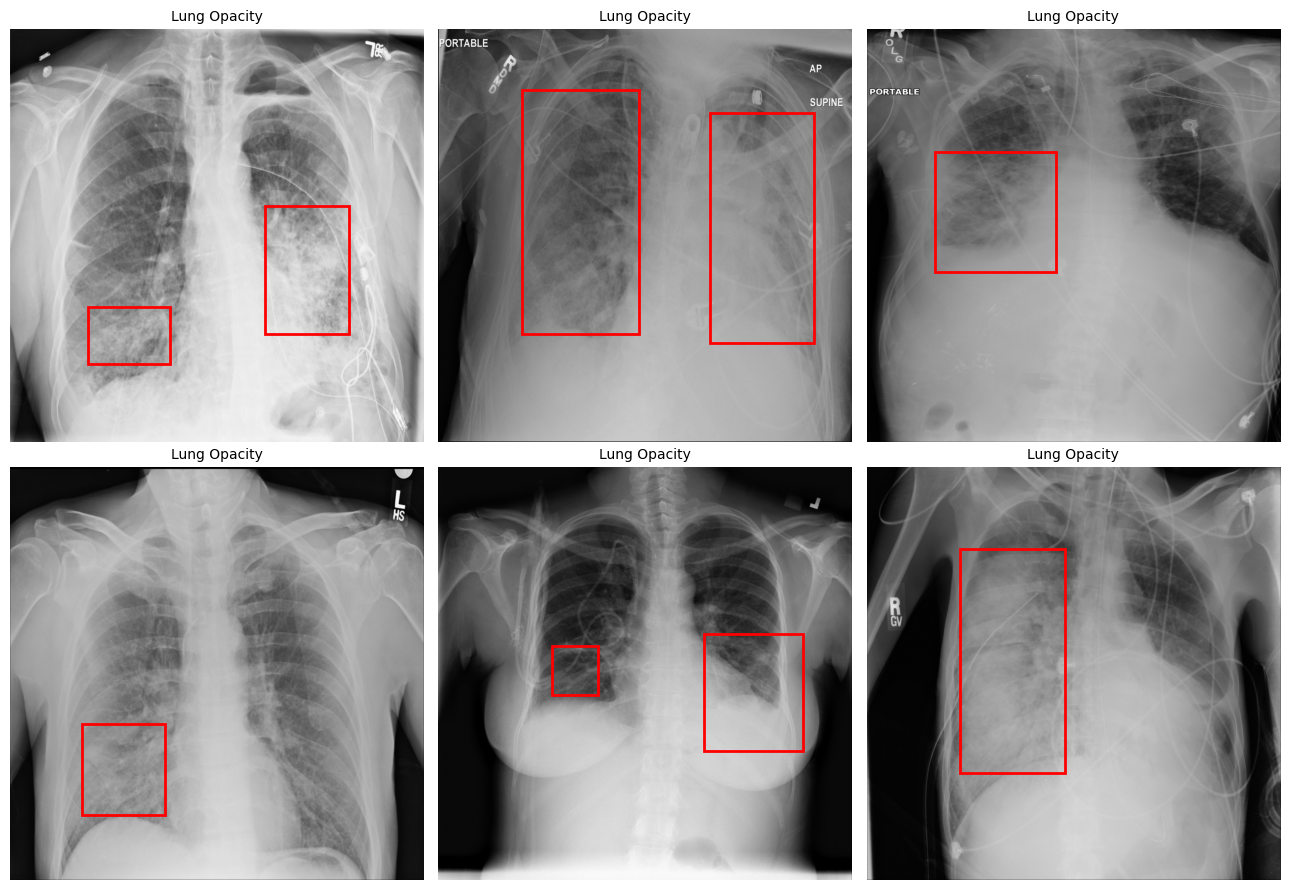

In [25]:
#@title A grid of random pneumonia cases (re-run for new examples) { display-mode: "form" }
pids = per_patient[per_patient["class"] == "Lung Opacity"]["patientId"].sample(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, pid in zip(axes.ravel(), pids):
    show_patient(pid, ax)
plt.tight_layout(); plt.show()

# 6. Distributions & geometry

The quantitative core of EDA: how balanced are the classes, how many boxes do positives have, where do the boxes fall, and are all images the same size?

## 6.1 Class balance
**Imbalance** (many more 0s than 1s) quietly hurts training — a lazy model can score well by always guessing the majority class. Count it now.

Target (per patient):
 Target
0    2250
1     750
Name: count, dtype: int64 

Class (per patient):
 class
No Lung Opacity / Not Normal    1259
Normal                           991
Lung Opacity                     750
Name: count, dtype: int64


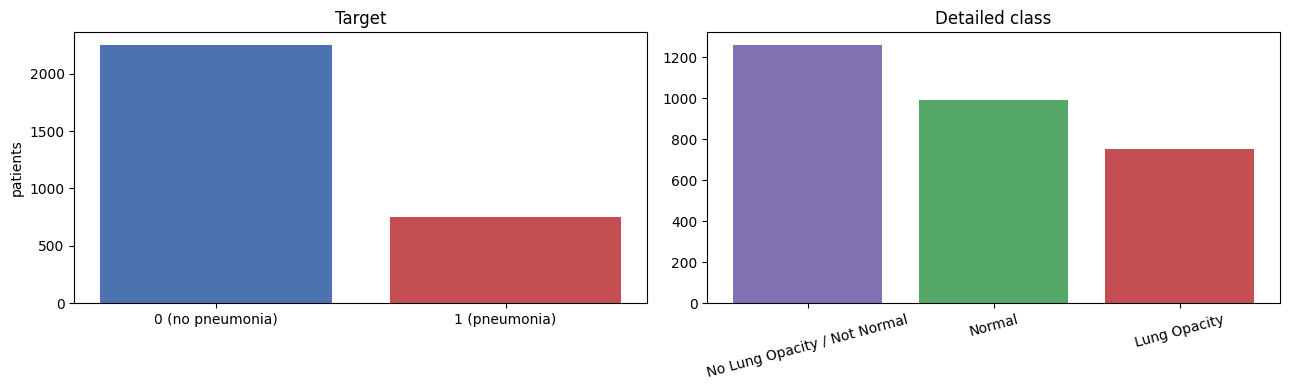


Negative : Positive  =  3.0 : 1


In [26]:
target_counts = per_patient["Target"].value_counts().sort_index()
class_counts  = per_patient["class"].value_counts()
print("Target (per patient):\n", target_counts, "\n")
print("Class (per patient):\n", class_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(["0 (no pneumonia)", "1 (pneumonia)"], target_counts.values, color=["#4C72B0", "#C44E52"])
axes[0].set_title("Target"); axes[0].set_ylabel("patients")
axes[1].bar(class_counts.index, class_counts.values, color=["#8172B3", "#55A868", "#C44E52"])
axes[1].set_title("Detailed class"); axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()
print(f"\nNegative : Positive  =  {target_counts[0]/target_counts[1]:.1f} : 1")

## 6.2 Boxes per positive patient
Some patients have pneumonia in more than one region, so they get multiple boxes.

1    308
2    429
3     12
4      1
Name: count, dtype: int64


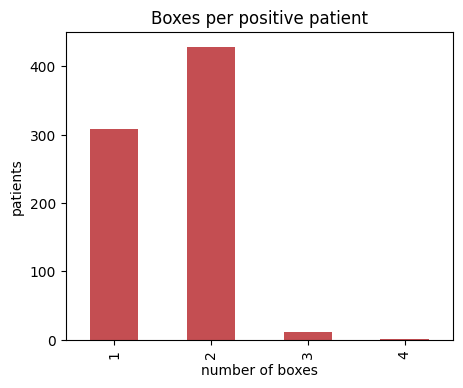

In [27]:
positives = train_labels[train_labels["Target"] == 1]
boxes_per = positives.groupby("patientId").size().value_counts().sort_index()
print(boxes_per)
boxes_per.plot(kind="bar", color="#C44E52", figsize=(5, 4))
plt.title("Boxes per positive patient"); plt.xlabel("number of boxes"); plt.ylabel("patients"); plt.show()

## 6.3 Bounding-box geometry
Where on the image do pneumonia boxes fall, and how big are they? Compute each box's **area** and **center**, then plot. (This is descriptive; we turn it into a testable hypothesis in Section 8.)

TypeError: '<=' not supported between instances of 'ellipsis' and 'ellipsis'

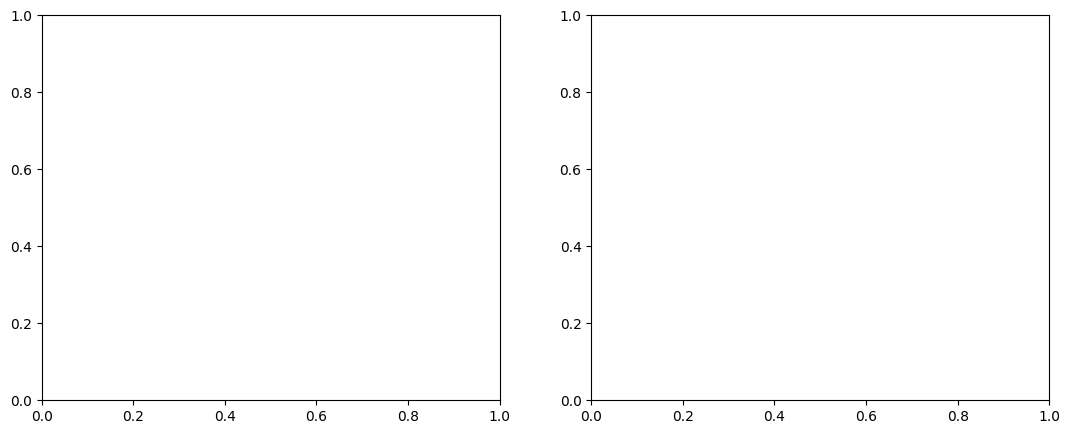

In [28]:
boxes = positives.copy()
# TODO: add three columns to `boxes`:
# area = width * height
# cx   = x + width / 2     (center x)
# cy   = y + height / 2    (center y)
boxes["area"] = ...  # YOUR CODE HERE
boxes["cx"]   = ...  # YOUR CODE HERE
boxes["cy"]   = ...  # YOUR CODE HERE

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(boxes["area"], bins=40, color="#4C72B0")
axes[0].set_title("Box area (pixels²)"); axes[0].set_xlabel("area")
axes[1].scatter(boxes["cx"], boxes["cy"], s=4, alpha=0.15, color="#C44E52")
axes[1].set_xlim(0, IMG_SIZE); axes[1].set_ylim(IMG_SIZE, 0); axes[1].set_aspect("equal")
axes[1].set_title(f"Box centers (over the {IMG_SIZE}×{IMG_SIZE} image)"); axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.tight_layout(); plt.show()

## 6.4 Are all images the same size?
We *assumed* the boxes live in a 1024×1024 space above. Don't assume — check. Reading just the image dimensions is fast.

In [29]:
n_sample = 300
sample_ids = per_patient["patientId"].sample(n_sample, random_state=SAMPLE_SEED)
sizes = [Image.open(TRAIN_IMG_DIR / f"{pid}.jpg").size for pid in sample_ids]
print(pd.Series([f"{w}x{h}" for (w, h) in sizes]).value_counts())

1024x1024    300
Name: count, dtype: int64


# 7. Metadata-driven EDA

The CSV carries clinical metadata: **age**, **sex**, and **view position** (AP vs PA). These often relate to who is sick and how the image was taken — and a model can secretly latch onto them. Look at their distributions, then at how the pneumonia rate varies across them.

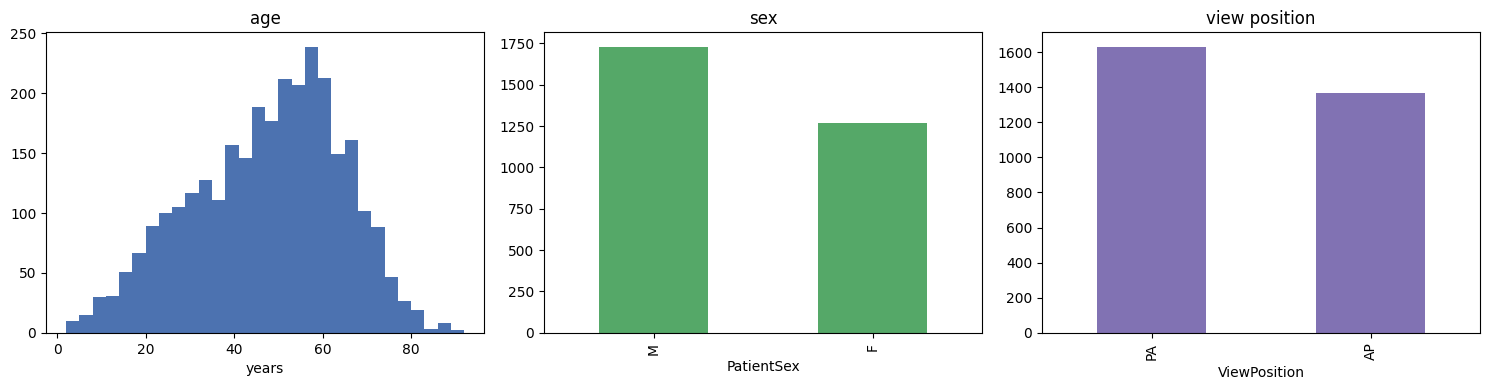

In [30]:
m = per_patient.copy()
m["PatientAge"] = pd.to_numeric(m["PatientAge"], errors="coerce")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(m["PatientAge"].dropna(), bins=30, color="#4C72B0"); axes[0].set_title("age"); axes[0].set_xlabel("years")
m["PatientSex"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868"); axes[1].set_title("sex")
m["ViewPosition"].value_counts().plot(kind="bar", ax=axes[2], color="#8172B3"); axes[2].set_title("view position")
plt.tight_layout(); plt.show()

Now the interesting part: does the **pneumonia rate** differ across groups? `groupby(col)["Target"].mean()` gives the fraction positive in each group.

In [ ]:
# Pneumonia rate (mean of Target) and group size (count) by view position.
# TODO: print pneumonia rate AND group size for each ViewPosition.
# hint: m.groupby("ViewPosition")["Target"].agg(["mean", "count"])
raise NotImplementedError("Compute pneumonia rate by view position, then delete this line.")

# 8. Hypotheses worth testing

Turn observations into **questions a model might exploit**. Each hypothesis below has a rationale and a starter — these are starting points, so extend them.

## 8.1 View position is associated with the label

AP views are often taken at the bedside for sicker, less mobile patients; PA is the standard upright view. If the pneumonia rate differs by view (you just measured this in Section 7), then **view position is a confounder**: a model could learn to read the *acquisition style* as a shortcut instead of the actual lung findings.

In [31]:
# Break the rate down further — does the view effect persist within each sex?
print(m.groupby(["PatientSex", "ViewPosition"])["Target"].agg(["mean", "count"]))
# Try it: does the gap hold across age groups too? (hint: pd.cut on PatientAge)

                             mean  count
PatientSex ViewPosition                 
F          AP            0.381720    558
           PA            0.115169    712
M          AP            0.413070    811
           PA            0.130577    919


## 8.2 Pneumonia location is spatially biased

If the box-center plot (Section 6.3) clusters in particular regions, **position carries signal** — a detector might exploit a location prior, and flips/crops in augmentation could break that. The starter splits boxes into halves.

In [32]:
half = IMG_SIZE / 2
print(f"left vs right (x < {int(half)}):")
print((boxes["cx"] < half).value_counts(normalize=True).rename({True: "left", False: "right"}))
print(f"\nupper vs lower (y < {int(half)}):")
print((boxes["cy"] < half).value_counts(normalize=True).rename({True: "upper", False: "lower"}))
# Try it: a 2D histogram of (cx, cy), or compare 1-box vs multi-box patients.

NameError: name 'IMG_SIZE' is not defined

## 8.3 Your own hypothesis

State a question, why it matters, and how you'd test it — then try it in the cell below. (Ideas: Does pneumonia rate rise with age? Is `BodyPartExamined`/`Modality` ever inconsistent? Do larger boxes concentrate anywhere?)

In [ ]:
# Question:
# Why it matters:
# How to test:

# YOUR EXPLORATION HERE

# 9. Limitations of the data

What this dataset does **not** give us:

- **Held-out test labels.** The `test` split ships only with a submission template, so you evaluate on `val` yourself and submit `test` predictions to the leaderboard. The splits were made **patient-wise**, so the same patient never appears in two splits (no leakage).
- **Class imbalance.** ~3× more negatives than positives, and the three detailed classes are uneven (Section 6.1).
- **Label meaning & ambiguity.** Labels are radiologists' annotations. "Lung Opacity" is a *finding consistent with* pneumonia, not a confirmed diagnosis; "No Lung Opacity / Not Normal" is a heterogeneous catch-all. Different readers disagree — treat labels as informed opinions, not absolute truth.
- **Boxes are approximate.** A box marks a region, not a precise outline, and exists only for positives.
- **Limited context.** One frontal view per patient; no labs, symptoms, or history.
- **Population shift.** One collection from specific sites — a model trained here may not transfer to a different hospital or population.

---

That completes the EDA. The patterns you found — the 3:1 imbalance, the view-position confounder, the spatial box prior — are exactly the things the **classification**, **localization**, and **bias-analysis** notebooks build on next.